In [1]:
import pandas as pd
import numpy as np
from functions.running import prepare_data
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.decomposition import PCA
from functions.training import train
from functions.networks import SimpleNN, FullNN
import shap

In [2]:
def topk_features_all_labels(shap_values, k=5):
    """
    Compute top-k important features across all labels and samples.
    
    shap_values: np.array, shape (n_samples, n_features, n_labels)
    k: number of features to select
    
    Returns:
        list of top-k feature indices
    """
    # Mean(|SHAP|) over samples and labels → importance per feature
    mean_shap_all = np.mean(np.abs(shap_values), axis=(0,2))  # shape: (n_features,)
    
    # Top-k feature indices
    topk_idx = np.argsort(-mean_shap_all)[:k]
    return topk_idx.tolist()

def topk_features_per_label(shap_values, k=5):
    """
    Compute top-k important features for each label separately.

    shap_values: np.array, shape (n_samples, n_features, n_labels)
    k: number of features to select per label

    Returns:
        dict: {label_index: [top-k feature indices]}
    """
    n_labels = shap_values.shape[2]
    top_features = {}

    for label in range(n_labels):
        # Mean(|SHAP|) over all samples → importance per feature for this label
        mean_shap_label = np.mean(np.abs(shap_values[:, :, label]), axis=0)
        # Top-k features
        topk_idx = np.argsort(-mean_shap_label)[:k]
        top_features[label] = topk_idx.tolist()
    
    return top_features


# ------------------------
# Perturbation functions
# ------------------------
def perturb_mean(sample, feature_indices, *_):
    x = sample.copy()
    mean_val = np.mean(sample)
    for f in feature_indices:
        x[f] = mean_val
    return x

def perturb_median(sample, feature_indices, *_):
    x = sample.copy()
    median_val = np.median(sample)
    for f in feature_indices:
        x[f] = median_val
    return x

def perturb_zero(sample, feature_indices, *_):
    x = sample.copy()
    for f in feature_indices:
        x[f] = 0
    return x

def perturb_marginal(sample, feature_indices, X_train, random_state=None):
    rng = np.random.RandomState(random_state)
    x = sample.copy()
    for f in feature_indices:
        x[f] = rng.choice(X_train[:, f])
    return x

# ------------------------
# Compute AOPC for tabular dataset
# ------------------------
def compute_AOPC_dataset(model, X, feature_indices, label=0, device='cpu', 
                         X_train=None, perturb_method='mean', random_state=None):
    """
    Compute AOPC for tabular data.

    model: torch model (binary/multi-label)
    X: np.array (n_samples, n_features)
    feature_indices: list of features to perturb
    label: target label index
    device: 'cpu' or 'cuda'
    X_train: training set needed for marginal perturb
    perturb_method: 'mean', 'median', 'zero', 'marginal'
    random_state: int, for reproducibility
    """
    # Choose perturb function
    if perturb_method == 'mean':
        perturb_fn = perturb_mean
        perturb_args = ()
    elif perturb_method == 'median':
        perturb_fn = perturb_median
        perturb_args = ()
    elif perturb_method == 'zero':
        perturb_fn = perturb_zero
        perturb_args = ()
    elif perturb_method == 'marginal':
        if X_train is None:
            raise ValueError("X_train must be provided for marginal perturbation")
        perturb_fn = perturb_marginal
        perturb_args = (X_train, random_state)
    else:
        raise ValueError(f"Unknown perturb_method: {perturb_method}")

    model.eval()
    n_samples = X.shape[0]
    deltas = []

    for i in range(n_samples):
        x_orig = X[i:i+1].astype(np.float32)
        x_tensor = torch.tensor(x_orig).to(device)
        with torch.no_grad():
            p_orig = torch.sigmoid(model(x_tensor))[0, label].item()

        x_pert = perturb_fn(x_orig[0], feature_indices, *perturb_args)
        x_pert_tensor = torch.tensor(x_pert.astype(np.float32)).unsqueeze(0).to(device)
        with torch.no_grad():
            p_new = torch.sigmoid(model(x_pert_tensor))[0, label].item()

        deltas.append(p_orig - p_new)

    mean_AOPC = np.mean(deltas)
    return deltas, mean_AOPC



In [3]:
df_train = pd.read_table('https://archive.ics.uci.edu/ml/machine-learning-databases/spect/SPECTF.train', header = None,sep=',')
df_test = pd.read_table('https://archive.ics.uci.edu/ml/machine-learning-databases/spect/SPECTF.test',
                     header=None, sep = ',')
df = pd.concat([df_train, df_test])
data = df.to_numpy()
X,y = data[:,1:], data[:,0]
G = len(np.unique(y))
for g in range(G):
  print(sum(y==g))
X = X.astype('float')

dataname = 'heart'
input_dim = X.shape[1]
epochs = 200
batch_size = 64
n_layer = 5
init_type = 'he'
dataname_ = dataname + str(n_layer) + init_type
missing = False
variance_retained = .95
criterion = nn.CrossEntropyLoss()
learning_rate = 0.01
n_frozen_epochs = 30

55
212


In [ ]:
n_seeds = 10
random_states = np.random.choice(range(1000, 2000), size=n_seeds, replace=False)
print("Random states:", random_states)

all_results = []

for random_state in random_states: 
    X_train, X_test, y_train, y_test = prepare_data(X,y, missing = missing, random_state=random_state)
    input_dim = X_train.shape[1]  # Number of features

    output_dim = len(np.unique(y_train))  # Number of classes (for Iris dataset)

    pca = PCA(n_components=variance_retained)
    pca.fit(X_train)
    n_components = pca.n_components_

    hidden_dim = n_components  # Hidden layer size

    other_layers = SimpleNN(input_dim=n_components, hidden_dim=hidden_dim, output_dim=output_dim, n_layer = n_layer, init_type = init_type)

    train_loader = torch.utils.data.DataLoader(list(zip(X_train, y_train)), batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(list(zip(X_test, y_test)), batch_size=batch_size, shuffle=False)


    print("Training with PCA-initialized NN...")
    pca_init_nn = FullNN(input_dim, n_components, other_layers, activation='none', init_type=init_type)
    pca_init_nn.init_pca_weights(X_train)  # Initialize weights with PCA components

    # train on everything except the first layer
    optimizer = optim.Adam([{'params': param} for name, param in pca_init_nn.named_parameters() if not name.startswith('fc1')],
                            lr=learning_rate)

    model_pcsinit, train_losses_pcinit, test_accuracies_pcinit, training_time_pcinit, test_probs_pcinit = train(
            pca_init_nn, train_loader, test_loader, criterion, optimizer, epochs=n_frozen_epochs
        )


    # train the complete network
    optimizer = optim.Adam(pca_init_nn.parameters(), lr=learning_rate)
    model_pcsinit2, train_losses_pcinit2, test_accuracies_pcinit2, training_time_pcinit2, test_probs_pcinit2 = train(pca_init_nn, train_loader, test_loader, criterion, optimizer, epochs=epochs-n_frozen_epochs)
    train_losses_pcinit = np.concatenate([train_losses_pcinit,train_losses_pcinit2])
    test_accuracies_pcinit = np.concatenate([test_accuracies_pcinit, test_accuracies_pcinit2])
    training_time_pcinit = np.concatenate([training_time_pcinit, training_time_pcinit2])
    test_probs_pcinit = np.concatenate([test_probs_pcinit, test_probs_pcinit2])

    # ====== Interpret Full Model After Training ======
    model_final = model_pcsinit2  # model đã fine-tune cả fc1
    model_final.eval()

    X_train_np = X_train.numpy() if hasattr(X_train, 'numpy') else X_train
    X_test_np  = X_test.numpy()  if hasattr(X_test, 'numpy') else X_test
    y_test_np  = y_test.numpy()  if hasattr(y_test, 'numpy') else y_test

    idx_class0 = np.where(y_test_np == 0)[0]
    idx_class1 = np.where(y_test_np == 1)[0]
    n_samples = min(len(idx_class0), len(idx_class1))  # balanced size

    np.random.seed(42)  # reproducible
    idx_class0_sample = np.random.choice(idx_class0, n_samples, replace=False)
    idx_class1_sample = np.random.choice(idx_class1, n_samples, replace=False)

    balanced_idx = np.concatenate([idx_class0_sample, idx_class1_sample])
    np.random.shuffle(balanced_idx)

    test_np_balanced = X_test_np[balanced_idx]
    y_test_balanced  = y_test_np[balanced_idx]

    print(f"Balanced test set shape: {test_np_balanced.shape}")
    print(f"Class counts: {np.bincount(y_test_balanced)}")  # should be [n_samples, n_samples]

    print("\n=== SHAP PCSINIT ===")
    background_np = X_train_np

    def pcsinit_torch_predict(x_numpy):
        x_torch = torch.tensor(x_numpy, dtype=torch.float32)
        with torch.no_grad():
            return model_final(x_torch).numpy()

    pcsinit_explainer = shap.KernelExplainer(pcsinit_torch_predict, background_np)
    pcsinit_shap_values = pcsinit_explainer.shap_values(test_np_balanced)
    results = []

    print(f"Random_state: {random_state}")
    ks = [1, 2, 3, 4, 5]

    for k in ks:
        top_features = topk_features_per_label(pcsinit_shap_values, k=k)
        print(f"Top {k} features: {top_features}")

        perturb_methods = ['mean', 'median', 'marginal', 'zero']
        for perturb_method in perturb_methods:
            print(f"perturb_method: {perturb_method}")

            deltas0, aopc0 = compute_AOPC_dataset(
                model_final, test_np_balanced[y_test_balanced==0], top_features[0], label=0,
                device='cpu', X_train=X_train,
                perturb_method=perturb_method, random_state=random_state
            )
            deltas1, aopc1 = compute_AOPC_dataset(
                model_final, test_np_balanced[y_test_balanced==1], top_features[1], label=1,
                device='cpu', X_train=X_train,
                perturb_method=perturb_method, random_state=random_state
            )
            print(f"AOPC label 0: {aopc0:.4f}, label 1: {aopc1:.4f}")

            # Lưu vào list tổng
            all_results.append({
                'random_state': random_state,
                'k': k,
                'perturb_method': perturb_method,
                'top_features_label0': top_features[0],
                'top_features_label1': top_features[1],
                'AOPC_label0': aopc0,
                'AOPC_label1': aopc1
            })

# Sau khi lặp hết tất cả random_state -> lưu CSV
df_results = pd.DataFrame(all_results)
df_results.to_csv('AOPC_PCsInit.csv', index=False)
print("Saved all results to AOPC_PCsInit.csv")


Random states: [1212 1462 1512 1431 1651 1013 1690 1515 1997 1549]
Training with PCA-initialized NN...
Number of PCA components: 23
Epoch 1/30, Training Loss: 0.4951, Testing Accuracy: 0.8025, Training Time: 0.0133
Epoch 2/30, Training Loss: 0.4134, Testing Accuracy: 0.8025, Training Time: 0.0234
Epoch 3/30, Training Loss: 0.3828, Testing Accuracy: 0.8025, Training Time: 0.0331
Epoch 4/30, Training Loss: 0.3570, Testing Accuracy: 0.8148, Training Time: 0.0426
Epoch 5/30, Training Loss: 0.3167, Testing Accuracy: 0.8148, Training Time: 0.0523
Epoch 6/30, Training Loss: 0.2744, Testing Accuracy: 0.8025, Training Time: 0.0608
Epoch 7/30, Training Loss: 0.2461, Testing Accuracy: 0.8025, Training Time: 0.0681
Epoch 8/30, Training Loss: 0.1999, Testing Accuracy: 0.7778, Training Time: 0.0751
Epoch 9/30, Training Loss: 0.1728, Testing Accuracy: 0.7778, Training Time: 0.0823
Epoch 10/30, Training Loss: 0.1361, Testing Accuracy: 0.7778, Training Time: 0.0894
Epoch 11/30, Training Loss: 0.1029, T

Using 186 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Epoch 148/170, Training Loss: 0.0000, Testing Accuracy: 0.7901, Training Time: 1.0981
Epoch 149/170, Training Loss: 0.0000, Testing Accuracy: 0.7901, Training Time: 1.1053
Epoch 150/170, Training Loss: 0.0000, Testing Accuracy: 0.7901, Training Time: 1.1141
Epoch 151/170, Training Loss: 0.0000, Testing Accuracy: 0.7901, Training Time: 1.1201
Epoch 152/170, Training Loss: 0.0000, Testing Accuracy: 0.7901, Training Time: 1.1278
Epoch 153/170, Training Loss: 0.0000, Testing Accuracy: 0.7901, Training Time: 1.1344
Epoch 154/170, Training Loss: 0.0000, Testing Accuracy: 0.7901, Training Time: 1.1414
Epoch 155/170, Training Loss: 0.0000, Testing Accuracy: 0.7901, Training Time: 1.1481
Epoch 156/170, Training Loss: 0.0000, Testing Accuracy: 0.7901, Training Time: 1.1547
Epoch 157/170, Training Loss: 0.0000, Testing Accuracy: 0.7901, Training Time: 1.1622
Epoch 158/170, Training Loss: 0.0000, Testing Accuracy: 0.7901, Training Time: 1.1700
Epoch 159/170, Training Loss: 0.0000, Testing Accuracy

  0%|          | 0/32 [00:00<?, ?it/s]

Random_state: 1212
Top 1 features: {0: [21], 1: [21]}
perturb_method: mean
AOPC label 0: -0.0449, label 1: 0.0078
perturb_method: median
AOPC label 0: -0.0469, label 1: 0.0143
perturb_method: marginal
AOPC label 0: 0.1520, label 1: -0.0014
perturb_method: zero
AOPC label 0: -0.0288, label 1: 0.0037
Top 2 features: {0: [21, 39], 1: [21, 39]}
perturb_method: mean
AOPC label 0: -0.0528, label 1: 0.0010
perturb_method: median
AOPC label 0: -0.0540, label 1: -0.0012
perturb_method: marginal
AOPC label 0: 0.1523, label 1: -0.0037
perturb_method: zero
AOPC label 0: 0.0316, label 1: 0.0007
Top 3 features: {0: [21, 39, 11], 1: [21, 39, 11]}
perturb_method: mean
AOPC label 0: -0.0419, label 1: 0.0002
perturb_method: median
AOPC label 0: -0.0621, label 1: -0.0021
perturb_method: marginal
AOPC label 0: 0.1928, label 1: -0.0151
perturb_method: zero
AOPC label 0: 0.1634, label 1: -0.0016
Top 4 features: {0: [21, 39, 11, 42], 1: [21, 39, 11, 29]}
perturb_method: mean
AOPC label 0: -0.0555, label 1: 0

...

Random_state: 1997
Top 1 features: {0: [2], 1: [2]}
perturb_method: mean
AOPC label 0: -0.0297, label 1: -0.0056
perturb_method: median
AOPC label 0: -0.0364, label 1: -0.0022
perturb_method: marginal
AOPC label 0: 0.4494, label 1: -0.1271
perturb_method: zero
AOPC label 0: 0.0735, label 1: -0.0170
Top 2 features: {0: [2, 11], 1: [2, 11]}
perturb_method: mean
AOPC label 0: 0.0141, label 1: 0.0137
perturb_method: median
AOPC label 0: -0.0032, label 1: 0.0164
perturb_method: marginal
AOPC label 0: 0.4322, label 1: -0.1223
perturb_method: zero
AOPC label 0: 0.0899, label 1: -0.0108
Top 3 features: {0: [2, 11, 39], 1: [2, 11, 39]}
perturb_method: mean
AOPC label 0: 0.0256, label 1: 0.0141
perturb_method: median
AOPC label 0: 0.0057, label 1: 0.0168
perturb_method: marginal
AOPC label 0: 0.4794, label 1: -0.1368
perturb_method: zero
AOPC label 0: 0.2126, label 1: -0.0154
Top 4 features: {0: [2, 11, 39, 32], 1: [2, 11, 39, 32]}
perturb_method: mean
AOPC label 0: 0.0266, label 1: 0.0610
pertu

Using 186 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Epoch 151/170, Training Loss: 0.0000, Testing Accuracy: 0.8025, Training Time: 1.3397
Epoch 152/170, Training Loss: 0.0000, Testing Accuracy: 0.8025, Training Time: 1.3501
Epoch 153/170, Training Loss: 0.0000, Testing Accuracy: 0.8025, Training Time: 1.3607
Epoch 154/170, Training Loss: 0.0000, Testing Accuracy: 0.8025, Training Time: 1.3699
Epoch 155/170, Training Loss: 0.0000, Testing Accuracy: 0.8025, Training Time: 1.3792
Epoch 156/170, Training Loss: 0.0000, Testing Accuracy: 0.8025, Training Time: 1.3890
Epoch 157/170, Training Loss: 0.0000, Testing Accuracy: 0.8025, Training Time: 1.3989
Epoch 158/170, Training Loss: 0.0000, Testing Accuracy: 0.8025, Training Time: 1.4071
Epoch 159/170, Training Loss: 0.0000, Testing Accuracy: 0.8025, Training Time: 1.4172
Epoch 160/170, Training Loss: 0.0000, Testing Accuracy: 0.8025, Training Time: 1.4260
Epoch 161/170, Training Loss: 0.0000, Testing Accuracy: 0.8025, Training Time: 1.4357
Epoch 162/170, Training Loss: 0.0000, Testing Accuracy

  0%|          | 0/24 [00:00<?, ?it/s]

Random_state: 1549
Top 1 features: {0: [25], 1: [25]}
perturb_method: mean
AOPC label 0: 0.0133, label 1: -0.0220
perturb_method: median
AOPC label 0: 0.0055, label 1: -0.0243
perturb_method: marginal
AOPC label 0: -0.0018, label 1: 0.0222
perturb_method: zero
AOPC label 0: 0.0228, label 1: -0.0323
Top 2 features: {0: [25, 38], 1: [25, 38]}
perturb_method: mean
AOPC label 0: -0.0255, label 1: -0.0219
perturb_method: median
AOPC label 0: -0.0246, label 1: -0.0191
perturb_method: marginal
AOPC label 0: 0.0179, label 1: 0.0284
perturb_method: zero
AOPC label 0: 0.0026, label 1: 0.0010
Top 3 features: {0: [25, 38, 29], 1: [25, 38, 39]}
perturb_method: mean
AOPC label 0: -0.0161, label 1: -0.0119
perturb_method: median
AOPC label 0: -0.0250, label 1: 0.0090
perturb_method: marginal
AOPC label 0: 0.0745, label 1: 0.0048
perturb_method: zero
AOPC label 0: 0.0784, label 1: -0.0037
Top 4 features: {0: [25, 38, 29, 39], 1: [25, 38, 39, 29]}
perturb_method: mean
AOPC label 0: 0.0294, label 1: -0.

In [5]:
aopc_df = pd.read_csv('/Volumes/Macintosh HD/Projects/PAPER/12.PCSINIT/AOPC_random_seed.csv')
aopc_df.head()

,random_state,k,perturb_method,top_features_label0,top_features_label1,AOPC_label0,AOPC_label1
0,1212,1,mean,[21],[21],-0.044929,0.007828
1,1212,1,median,[21],[21],-0.046944,0.014268
2,1212,1,marginal,[21],[21],0.151963,-0.001403
3,1212,1,zero,[21],[21],-0.028774,0.003741
4,1212,2,mean,"[21, 39]","[21, 39]",-0.052762,0.000963


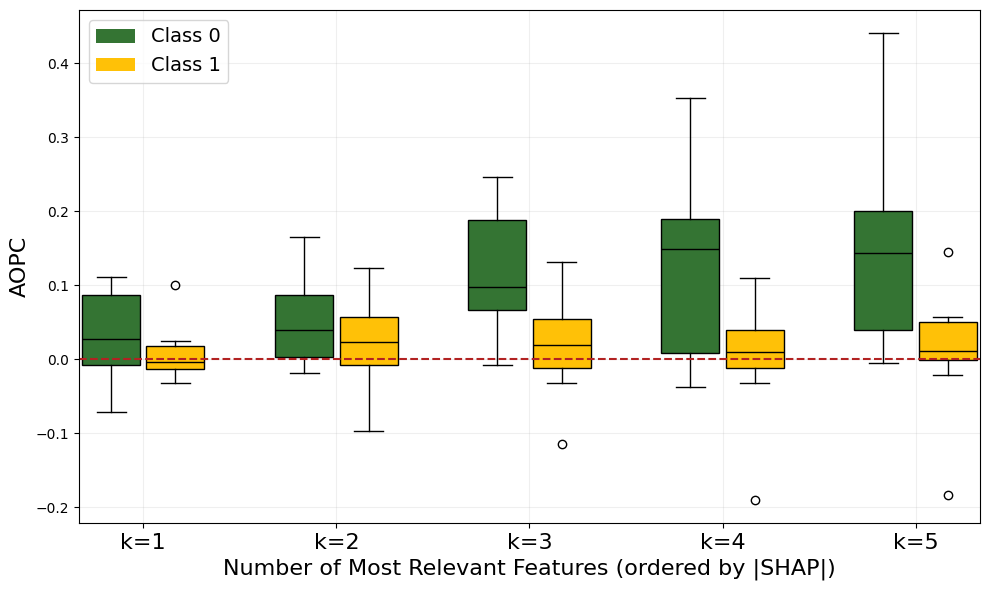

In [6]:
import matplotlib.pyplot as plt

# Filter the dataframe
df_plot = aopc_df[
    (aopc_df['perturb_method'] == 'zero') &
    (aopc_df['k'].isin([1, 2, 3, 4,5]))
].copy()

# Labels and k values
labels = ['AOPC_label0','AOPC_label1']
classes = ['Class 0','Class 1']
ks = [1, 2, 3,4,5]

# Prepare data for boxplot: a list of lists
data_to_plot = []
for k in ks:
    for label in labels:
        data = df_plot[df_plot['k']==k][label].values
        data_to_plot.append(data)

# Positions for grouped boxplots
positions = []
for i, k in enumerate(ks):
    positions.extend([i*3+2, i*3+3])  # 2 boxes per k

# Colors
colors = ['#347433','#FFC107']*len(ks)

# Create figure
fig, ax = plt.subplots(figsize=(10,6))

# Plot boxes
bp = ax.boxplot(data_to_plot, positions=positions, widths=0.9, patch_artist=True, showfliers=True)

# Set box colors
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
# Highlight medians in gray

for i, line in enumerate(bp['medians']):
    line.set_color('black')
    line.set_linewidth(1)

# Set x-ticks in the middle of each group
ax.set_xticks([np.mean([positions[i*2], positions[i*2+1]]) for i in range(len(ks))])
ax.set_xticklabels([f'k={k}' for k in ks], fontsize=16)

# Y-label, title
ax.set_ylabel('AOPC', fontsize=16)
ax.set_xlabel('Number of Most Relevant Features (ordered by |SHAP|)', fontsize=16)
#ax.set_title("AOPC Distribution per Class across 10 runs using zero perturbation", fontsize=18)
ax.grid(True, alpha=0.2)
ax.axhline(y=0, color='#B22222', linewidth=1.5, linestyle='--')

# Add legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#347433', label='Class 0'),
                   Patch(facecolor='#FFC107', label='Class 1')]
ax.legend(handles=legend_elements, fontsize=14)



plt.tight_layout()

plt.savefig('AOPC.pdf', dpi=300, bbox_inches='tight')
plt.show()